In [1]:
# Step 5 - SHAP Analysis on XGBoost (Best Model)
# Objective 2: Explainable ML Feature Prioritisation

# What this step does:
#   1. Loads trained XGBoost pipeline from Step 4
#   2. Computes SHAP values using TreeExplainer (exact, fast)
#   3. Global feature importance - top variants by mean |SHAP|
#   4. Beeswarm plot - direction and magnitude of each feature
#   5. Waterfall plot - single sample explanation
#   6. Annotates top SHAP features with gene names from GFF
#   7. Flags which top SHAP features are compensatory mutations
#   8. Cross-model consensus - SHAP vs RF vs EBM agreement

In [1]:
import os, warnings, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')
import shap
import xgboost as xgb
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

In [2]:
HOME   = os.path.expanduser("~")
BASE   = os.path.join(HOME, "tb_pipeline")
ML_OUT = os.path.join(BASE, "ml_outputs")
STEP1  = os.path.join(ML_OUT, "step1_dataset")
STEP4  = os.path.join(ML_OUT, "step4_models")
STEP5  = os.path.join(ML_OUT, "step5_shap")
os.makedirs(STEP5, exist_ok=True)

print(f"Step 4 inputs : {STEP4}")
print(f"Step 5 outputs: {STEP5}")

Step 4 inputs : /home/sukhjot/tb_pipeline/ml_outputs/step4_models
Step 5 outputs: /home/sukhjot/tb_pipeline/ml_outputs/step5_shap


### Data loading and model 

In [3]:
x_data = np.load(os.path.join(STEP1, "X_array.npy"))
y      = np.load(os.path.join(STEP1, "y_mdr_array.npy"))
labels = pd.read_csv(os.path.join(STEP1, "y_labels.csv"))

with open(os.path.join(STEP1, "feature_names_clean.txt")) as f:
    feature_names = [line.strip() for line in f if line.strip()]

In [4]:
xgb_pipe = pickle.load(
    open(os.path.join(STEP4, "trained_models", "xgb_pipeline.pkl"), 'rb')
)
xgb_model = xgb_pipe['model']  

In [5]:
print(type(xgb_pipe))

print(type(xgb_model))

print(xgb_model.n_features_in_)

print(x_data.shape)

print("Model features:", xgb_model.n_features_in_)
print("Dataset features:", x_data.shape[1])

print("Booster feature names:", xgb_model.get_booster().feature_names is None)

<class 'sklearn.pipeline.Pipeline'>
<class 'xgboost.sklearn.XGBClassifier'>
94583
(1858, 94583)
Model features: 94583
Dataset features: 94583
Booster feature names: True


In [6]:
assert x_data.shape[0] == len(y)
assert x_data.shape[1] == len(feature_names)

### Computing SHAP values

In [7]:
print("SHAP:", shap.__version__)
print("XGBoost:", xgb.__version__)

SHAP: 0.49.1
XGBoost: 2.1.4


In [8]:
print("computing SHAP values...")
t0 = time.time()

# casting to float32
# x_data is uint8 by default; SHAP and XGBoost require float32 so without this cast, SHAP values collapse near zero

X_float32 = x_data.astype(np.float32)

explainer   = shap.TreeExplainer(
    xgb_model,
    model_output="raw",                      # log-odds scale
    feature_perturbation="tree_path_dependent"
)
shap_values = explainer.shap_values(X_float32, check_additivity=False)

print(f"explainer finished in {time.time()-t0:.1f}s")
print(f"SHAP values shape: {shap_values.shape}")
print(f"SHAP value range: {shap_values.min():.4f} to {shap_values.max():.4f}")
print(f"expected value: {explainer.expected_value:.4f}")

computing SHAP values...
explainer finished in 31.0s
SHAP values shape: (1858, 94583)
SHAP value range: -2.0370 to 2.7234
expected value: 0.0366


In [9]:
np.save(os.path.join(STEP5, "shap_values.npy"), shap_values)
print("Saved: shap_values.npy")

Saved: shap_values.npy


### Global feature importance

In [10]:
shap_importance = pd.DataFrame({
    "feature_idx": np.arange(len(feature_names)),
    "variant_id": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap": shap_values.mean(axis=0),
    "max_shap": shap_values.max(axis=0),
    "min_shap": shap_values.min(axis=0),
    "pct_nonzero": (shap_values != 0).mean(axis=0) * 100,
})

shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance["rank"] = np.arange(1, len(shap_importance)+1)

In [11]:
#saving full table
shap_importance.to_csv(os.path.join(STEP5, 'obj2_shap_all_features.csv'), index=False)

print(f"Saved: obj2_shap_all_features.csv ({len(shap_importance):,} features)")
print()
print("Top 20 features by mean |SHAP|:")
print(shap_importance[['rank','variant_id','mean_abs_shap', 'mean_shap','pct_nonzero']].head(20).to_string(index=False))

Saved: obj2_shap_all_features.csv (94,583 features)

Top 20 features by mean |SHAP|:
 rank                                                variant_id  mean_abs_shap  mean_shap  pct_nonzero
    1                                    Chromosome_2155168_C_G       1.822415   0.077563        100.0
    2                                     Chromosome_761155_C_T       0.806041  -0.169270        100.0
    3                                    Chromosome_1673425_C_T       0.467836  -0.132888        100.0
    4                                    Chromosome_4247429_A_G       0.448759   0.041650        100.0
    5                                    Chromosome_4247431_G_C       0.264125  -0.002951        100.0
    6                                     Chromosome_761110_A_T       0.209169   0.017978        100.0
    7                                     Chromosome_840217_C_G       0.189936  -0.008835        100.0
    8 Chromosome_71584_C_CCGAGCGCTGTTCTGGCGCTAATCTGACGCTAGAATAG       0.170827   0.042493  

### Top 30 shap bar chart 

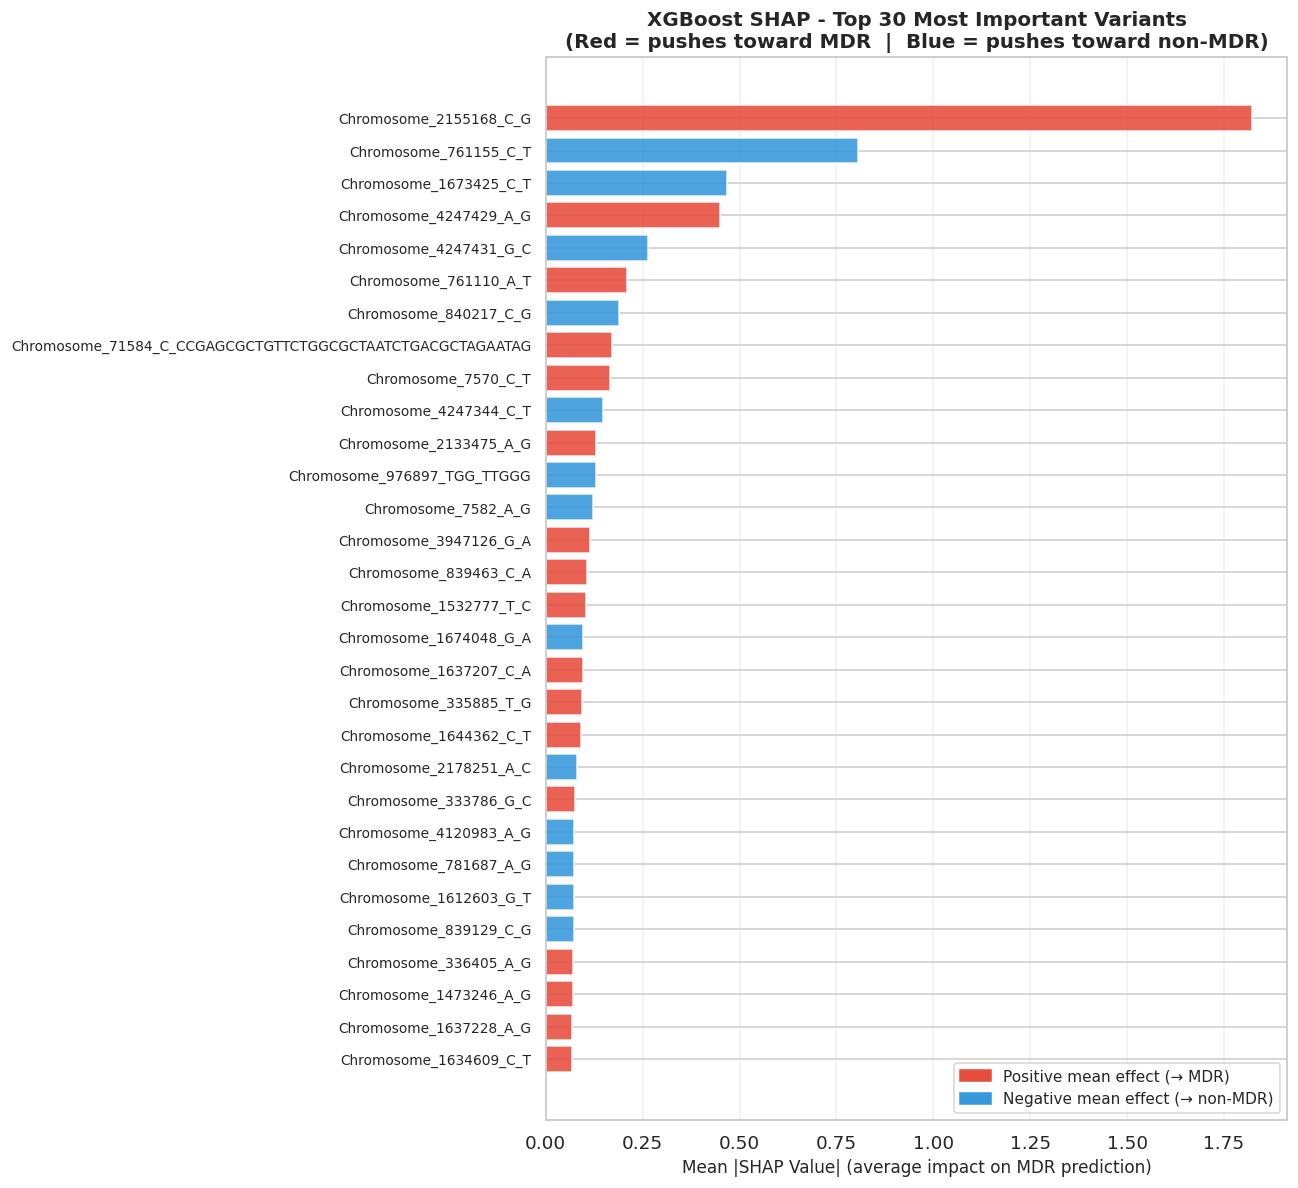

Saved: obj2_shap_top30_bar.png


In [12]:
top30 = shap_importance.head(30)

fig, ax = plt.subplots(figsize=(12, 11))

bar_colors = ['#e74c3c' if i > 0 else '#3498db' for i in top30['mean_shap'].values[::-1]]

bars = ax.barh(
    range(30),
    top30['mean_abs_shap'].values[::-1],
    color=bar_colors, alpha=0.88, edgecolor='white'
)

ax.set_yticks(range(30))
ax.set_yticklabels(top30['variant_id'].values[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP Value| (average impact on MDR prediction)', fontsize=11)
ax.set_title('XGBoost SHAP - Top 30 Most Important Variants\n'
             '(Red = pushes toward MDR  |  Blue = pushes toward non-MDR)',
             fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')


red_patch  = mpatches.Patch(color='#e74c3c', label='Positive mean effect (→ MDR)')
blue_patch = mpatches.Patch(color='#3498db', label='Negative mean effect (→ non-MDR)')
ax.legend(handles=[red_patch, blue_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_top30_bar.png'), bbox_inches='tight')
plt.show()
print("Saved: obj2_shap_top30_bar.png")

### Beeswarm Plot

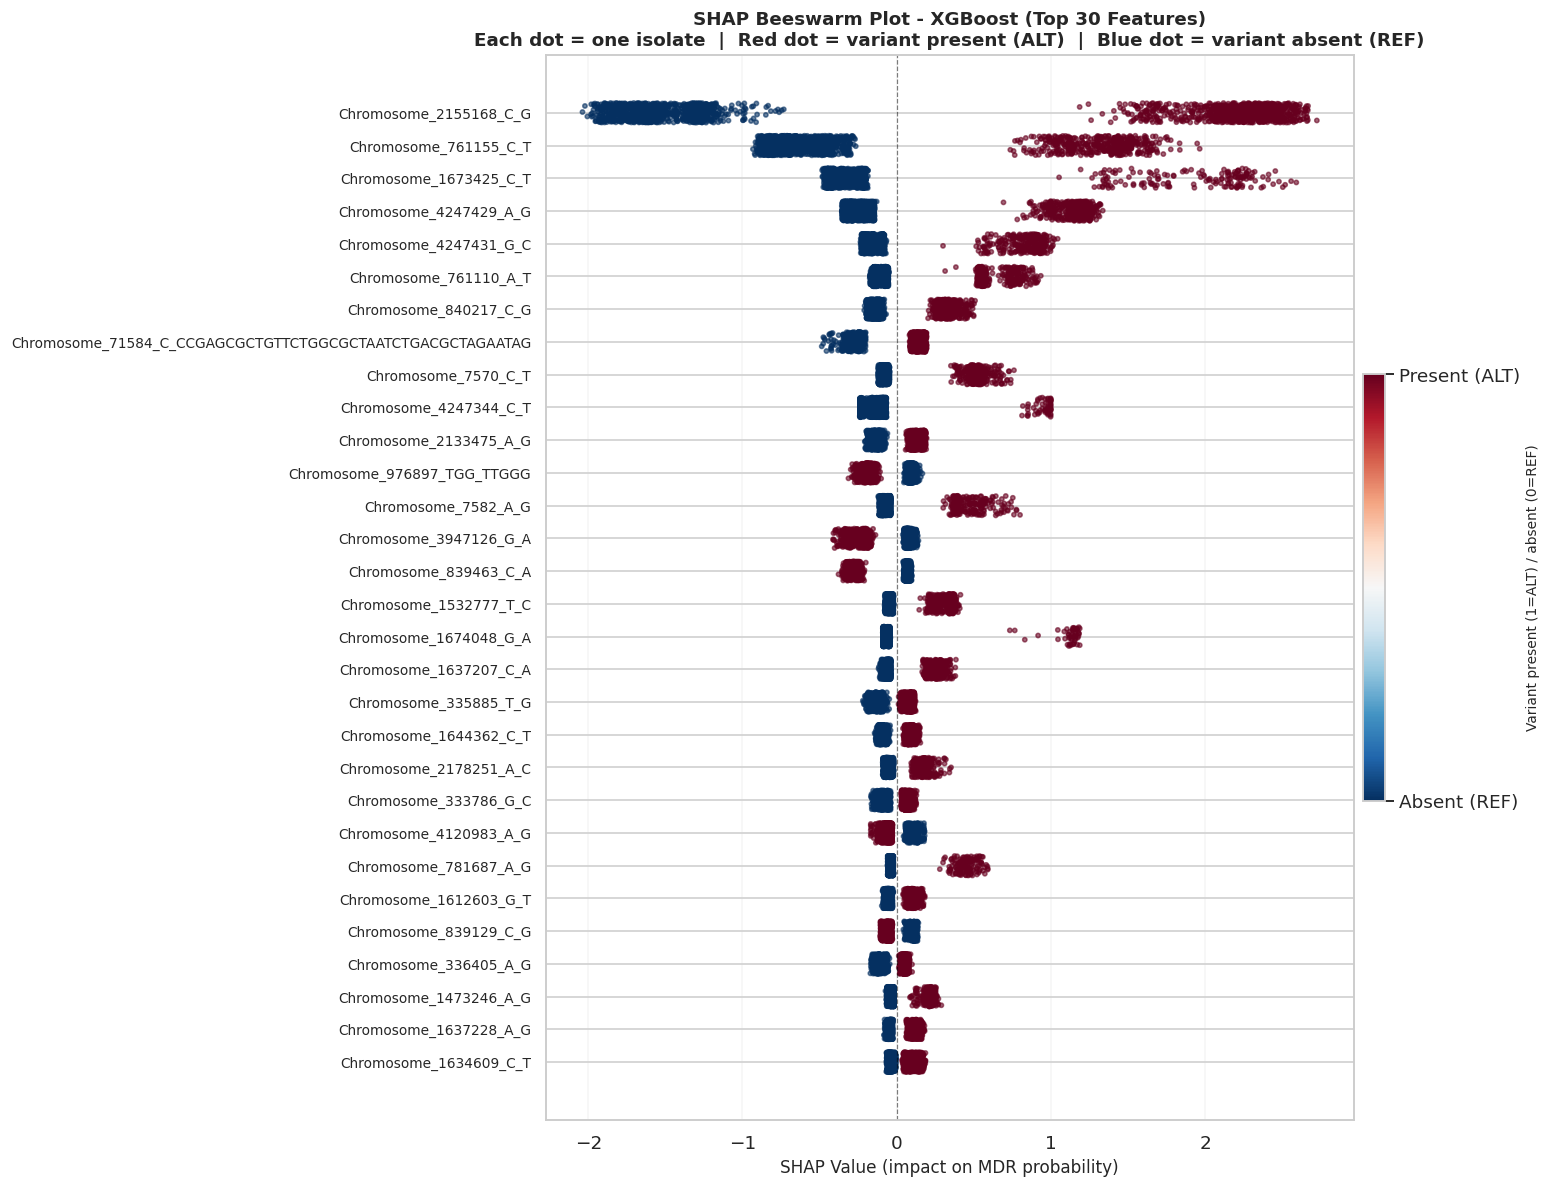

Saved: obj2_shap_beeswarm.png


In [13]:
# Beeswarm is the standard SHAP publication plot in which each dot = one sample
# here x axis = SHAP value (impact on prediction), color  = feature value (red=1/ALT present, blue=0/REF) and Y axis = feature ranked by mean |SHAP| (most important at top)
# and am using top 30 feature indices

top30_idx = shap_importance.head(30)["feature_idx"].values
top30_names = shap_importance.head(30)['variant_id'].values

# Subset SHAP values and X_data to top 30 features
shap_top30 = shap_values[:, top30_idx]
X_top30    = x_data[:, top30_idx].astype(float)

fig, ax = plt.subplots(figsize=(14, 11))

# Manual beeswarm implementation for clean publication figure
for rank_i, feat_i in enumerate(range(29, -1, -1)):   # top at y=29 (top of plot)
    feat_shap = shap_top30[:, feat_i]
    feat_val  = X_top30[:, feat_i]

    # Jitter y to separate overlapping points
    y_base = rank_i
    y_jitter = np.random.uniform(-0.3, 0.3, size=len(feat_shap))

    ax.scatter(
        feat_shap,
        y_base + y_jitter,
        c=feat_val,
        cmap='RdBu_r',
        vmin=0, vmax=1,
        s=8, alpha=0.6,
        rasterized=True   # rasterize for smaller file size
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_yticks(range(30))
ax.set_yticklabels(top30_names[::-1], fontsize=9)
ax.set_xlabel('SHAP Value (impact on MDR probability)', fontsize=11)
ax.set_title('SHAP Beeswarm Plot - XGBoost (Top 30 Features)\n'
             'Each dot = one isolate  |  Red dot = variant present (ALT)  |  Blue dot = variant absent (REF)',
             fontweight='bold', fontsize=12)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.01)
cbar.set_label('Variant present (1=ALT) / absent (0=REF)', fontsize=9)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Absent (REF)', 'Present (ALT)'])

ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_beeswarm.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: obj2_shap_beeswarm.png")

### SHAP summary using SHAP library 

Generating official SHAP summary plot...


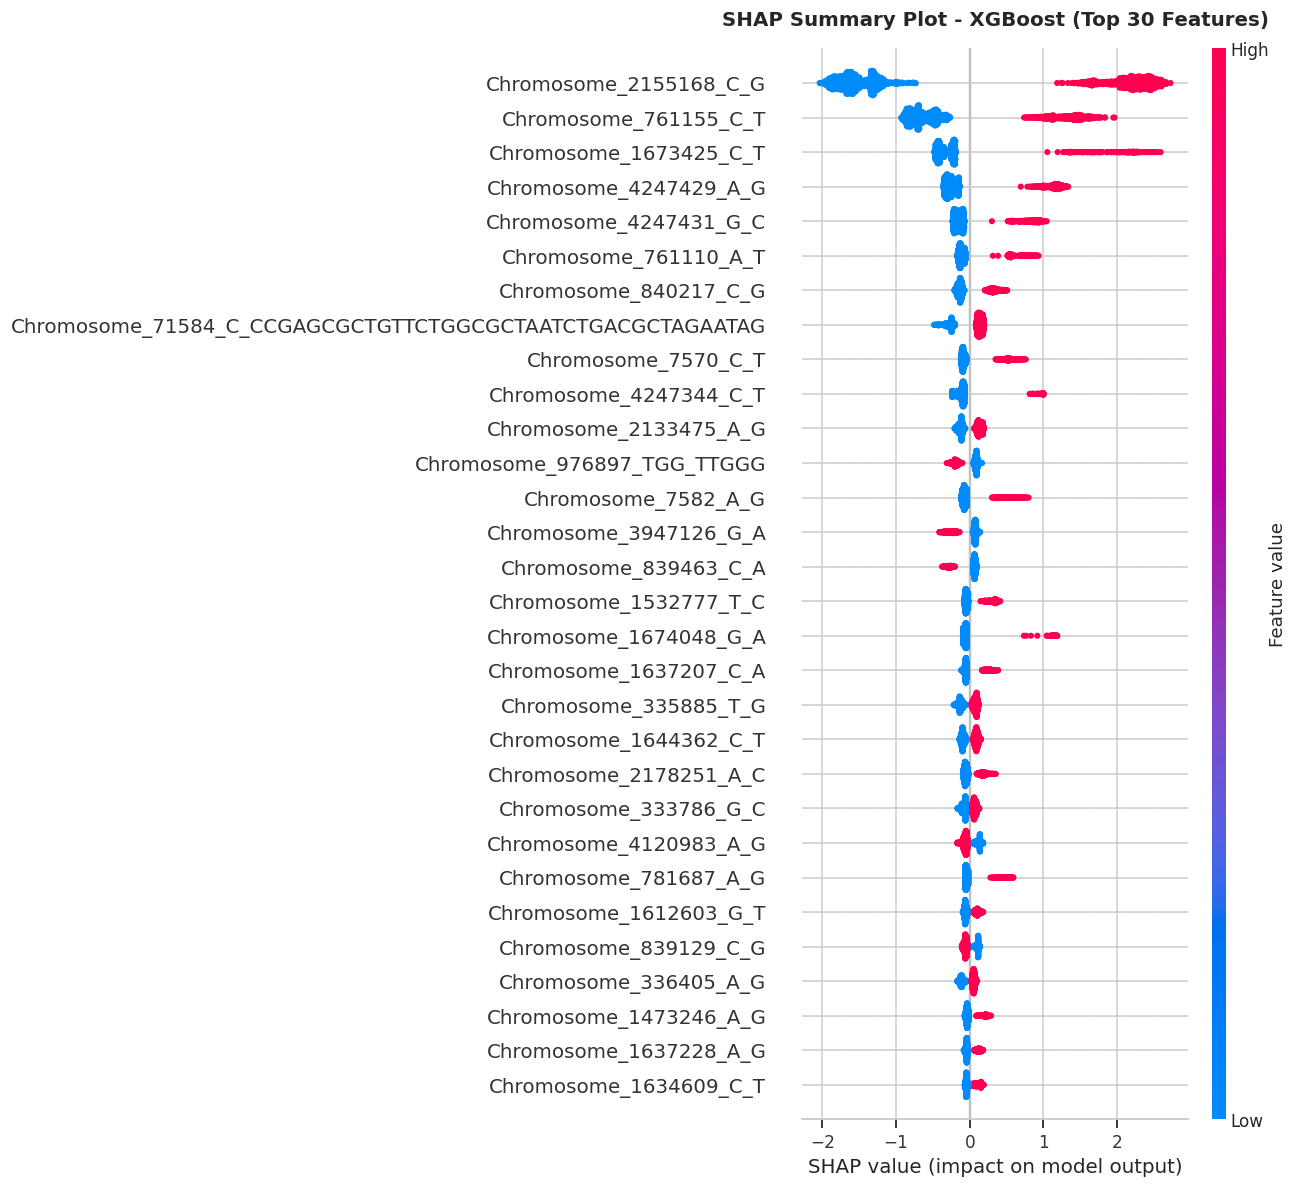

Saved: obj2_shap_summary.png


In [14]:
# Official SHAP library summary plot - standard in publications
print("Generating official SHAP summary plot...")

# Get top 30 features for summary plot
top30_idx = shap_importance.head(30)["feature_idx"].values
top30_names = shap_importance.head(30)['variant_id'].values

shap_top30 = shap_values[:, top30_idx]
X_top30 = x_data[:, top30_idx].astype(float)

plt.figure(figsize=(12, 11))
shap.summary_plot(
    shap_top30,
    X_top30,
    feature_names=top30_names,
    max_display=30,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary Plot - XGBoost (Top 30 Features)', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_summary.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: obj2_shap_summary.png")

### Waterfall Plot

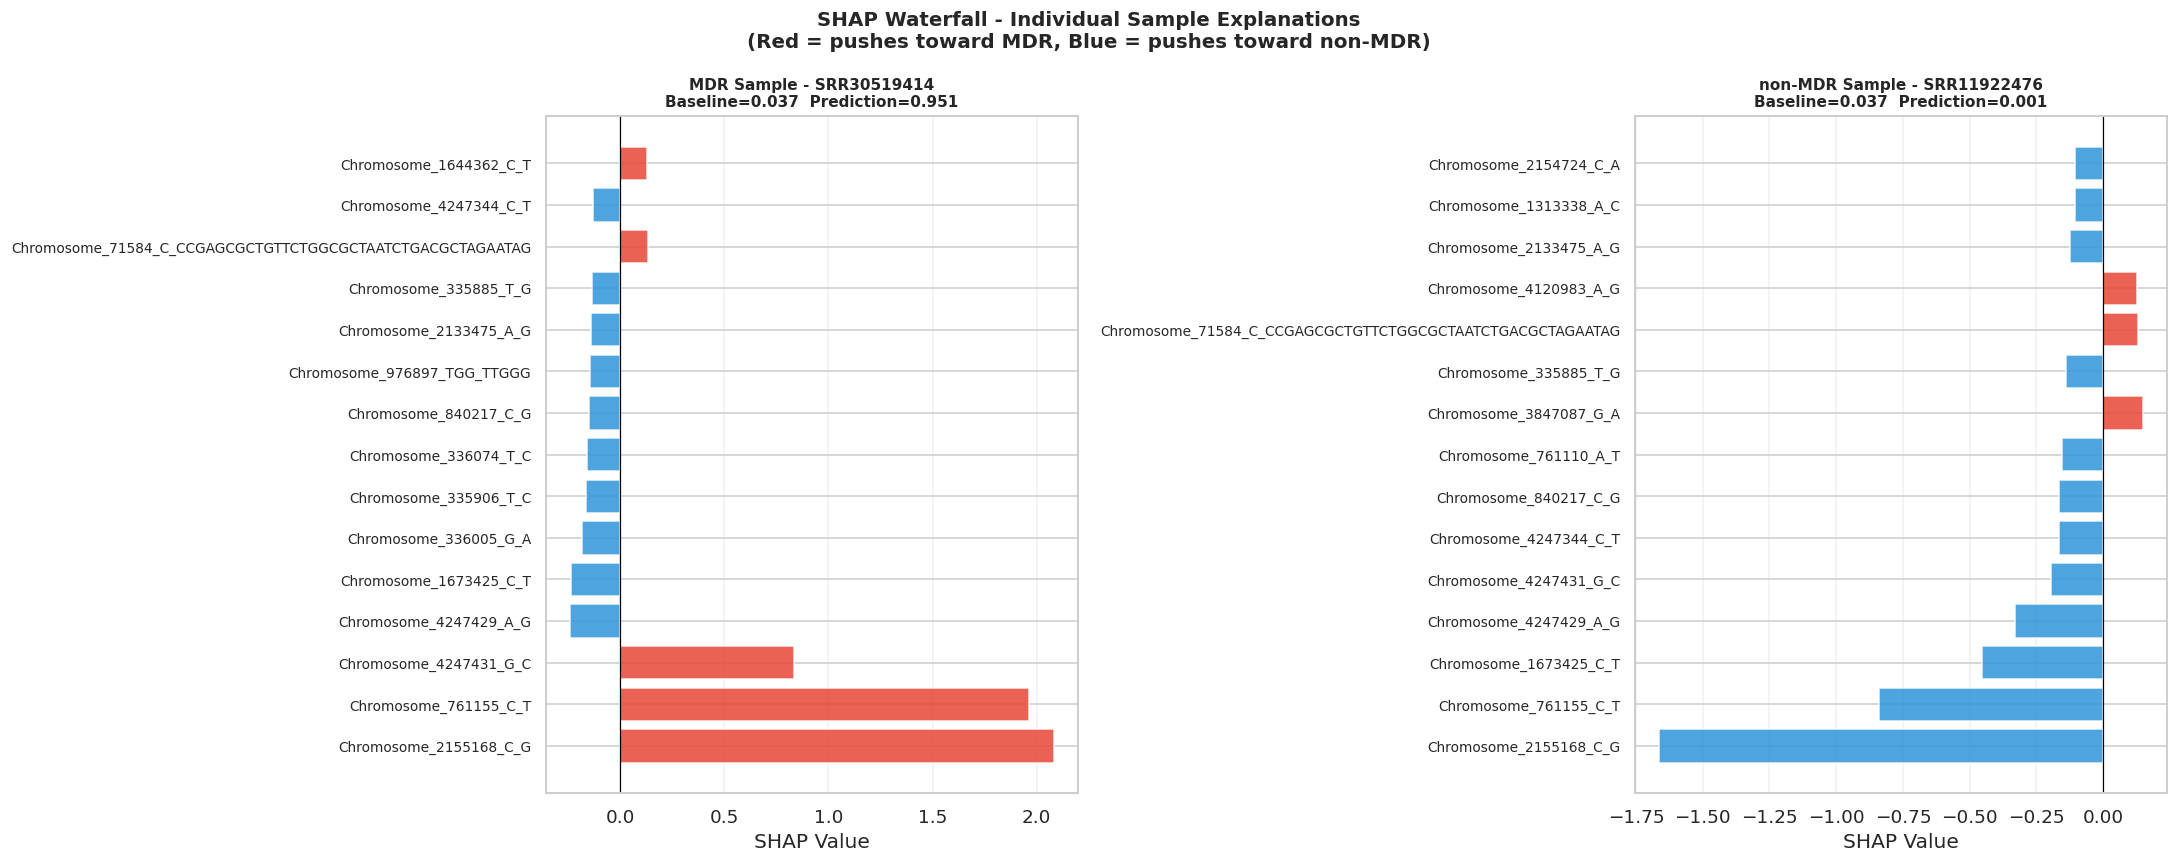

Saved: obj2_shap_waterfall.png


In [15]:
# Waterfall plot shows how one specific isolate's prediction was built
# up from the baseline, feature by feature

# Pick one MDR and one non-MDR sample to explain
mdr_idx  = np.where(y == 1)[0][0]    # first MDR sample
susc_idx = np.where(y == 0)[0][0]    # first non-MDR sample

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, sample_idx, label in [
    (axes[0], mdr_idx,  f'MDR Sample - {labels.iloc[mdr_idx]["sample_id"]}'),
    (axes[1], susc_idx, f'non-MDR Sample - {labels.iloc[susc_idx]["sample_id"]}')
]:
    # Get top 15 features for this sample by |SHAP|
    sample_shap = shap_values[sample_idx]
    top15_idx = np.abs(sample_shap).argsort()[-15:]
    top15_names = [feature_names[i] for i in top15_idx]
    top15_vals  = sample_shap[top15_idx]

    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top15_vals[::-1]]
    ax.barh(range(15), top15_vals[::-1], color=colors, alpha=0.88)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top15_names[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP Value')
    ax.set_title(f'{label}\nBaseline={explainer.expected_value:.3f}  '
                 f'Prediction={xgb_model.predict_proba(x_data[[sample_idx]])[0,1]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('SHAP Waterfall - Individual Sample Explanations\n'
             '(Red = pushes toward MDR, Blue = pushes toward non-MDR)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_waterfall.png'), bbox_inches='tight')
plt.show()
print("Saved: obj2_shap_waterfall.png")

### Gene annotation of top SHAP features

The Original BugThe pipeline was mislabeling real genes as "intergenic" (regions of DNA between genes) and assigning wrong gene names to specific locations. For example, a variant at position 1,313,338 was incorrectly labeled as the kasA gene.Why it happened:The Hardcoded Dictionary: The developers used a manually typed dictionary (KNOWN_GENES) containing coordinates for only about 24 genes.The Ignored File: The pipeline actually loaded an official, comprehensive genomic database file (the GFF), but the code forgot to use it.The Consequence: If a variant fell outside those 24 hardcoded genes, the system automatically called it "intergenic." If a position matched a flawed coordinate in that dictionary, it got a false label. In reality, position 1,313,338 is genuinely intergenic, sitting in a 400-base-pair gap between genes Rv1179c and pks3. The kasA gene lives far away (positions 2,518,115–2,519,365).🛠️ The Fix: Authoritative Tiered LookupThe developers deleted the broken 24-gene dictionary. They replaced it with a single, reliable lookup strategy that uses two main steps: a Primary source and a Fallback source.Step 1: Primary Source (TB-Profiler Catalogues)The pipeline first checks TB-Profiler (a tool used to find drug-resistance mutations). Since TB-Profiler focuses on known clinical variants, its data is highly trusted. It checks three of its files in order of strict priority:dr_variants.csv (Highest priority: curated drug-resistance mutations).compensatory.csv (Medium priority: mutations that offset the fitness cost of resistance).other_variants.csv (Lowest priority: a catch-all bucket for other noted mutations).Note on conflict resolution: If different patient samples show different gene names for the exact same genetic position within these files, the script counts them up and lets the majority vote win, logging the conflict for transparency.Step 2: Fallback Source (GFF Interval Lookup)TB-Profiler only cares about mutations linked to drug resistance. It ignores the other ~95% of the 94,583 genetic variants found in the research matrix.To prevent thousands of those standard variants from being falsely labeled "intergenic," the pipeline now uses a fallback:If TB-Profiler has no record of the position, the script looks up the exact coordinates in the official GFF file.This fallback code is shared exactly with another script in the pipeline (comparative_analysis.py), ensuring that Step 2 and Step 5 of the workflow always yield identical, consistent results.🎯 Summary of BenefitsAccuracy: Eliminates false "intergenic" labels for thousands of valid genes.Consistency: Prevents different parts of the pipeline from disagreeing with each other.Maintainability: Removes redundant, hardcoded coordinates that are prone to human typing errors.

In [16]:
TB_OUT               = os.path.join(BASE, "tbprofiler_results")
GFF_PATH              = os.path.join(BASE, "reference", "GCF_000195955.2_ASM19595v2_genomic.gff")
GENE_ANNOTATION_PATH  = os.path.join(STEP1, "variant_metadata_with_genes.csv")
CONFLICTS_PATH        = os.path.join(STEP5, "gene_annotation_conflicts.csv")

COMPENSATORY_GENES = {
    'rpoA', 'rpoC', 'ahpC', 'kasA', 'ndh', 'gyrB', 'gid',
    'mmpL5', 'mmpR5', 'Rv0678', 'embR', 'whiB7', 'eis'
    # Rv0678 added - same gene as mmpR5. Without this, this notebook and Step 2 disagree on
    # is_primary_DR/is_compensatory for every variant at this locus.
}
PRIMARY_DR_GENES = {
    'rpoB', 'katG', 'inhA', 'embB', 'embA', 'embC',
    'pncA', 'gyrA', 'rrs', 'rpsL', 'tlyA', 'ethA',
    'rplC', 'fgd1', 'dprE1', 'pepQ', 'atpE',
    # previously missing from this notebook's set even though comparative_analysis.py
    # (Step 2) already included them - see collate.py's own comments for why each
    # is primary-DR, not compensatory. Rv0678 intentionally NOT added here (see
    # COMPENSATORY_GENES above).
}

# Source files in authority order: dr_variants (curated known-DR calls) wins
# over compensatory, which wins over other_variants (TB-Profiler's catch-all).
TBPROFILER_SOURCES = [
    ("dr_variants",    os.path.join(TB_OUT, "dr_variants.csv")),
    ("compensatory",   os.path.join(TB_OUT, "compensatory.csv")),
    ("other_variants", os.path.join(TB_OUT, "other_variants.csv")),
]


def build_tbprofiler_gene_map():
    """PRIMARY source: pos -> gene, resolved by file authority then by
    majority vote within a file. Also returns a conflicts table listing
    every position where more than one gene name appeared anywhere across
    the three files."""
    calls_by_pos = {}  # pos -> {source_name: {gene: row_count}}
    for src_name, path in TBPROFILER_SOURCES:
        if not os.path.exists(path):
            print(f"  [skip] {src_name}: not found at {path}")
            continue
        df = pd.read_csv(path)
        counts = df.groupby(['pos', 'gene']).size().reset_index(name='n')
        for pos, sub in counts.groupby('pos'):
            calls_by_pos.setdefault(pos, {})[src_name] = dict(zip(sub['gene'], sub['n']))
        print(f"  [ok] {src_name}: {len(df):,} rows, {df['pos'].nunique():,} unique positions")

    pos_gene_map, conflict_rows = {}, []
    for pos, by_source in calls_by_pos.items():
        resolved_gene = resolved_from = None
        for src_name, _ in TBPROFILER_SOURCES:
            if src_name in by_source:
                gene_counts   = by_source[src_name]
                resolved_gene = max(gene_counts.items(), key=lambda kv: kv[1])[0]
                resolved_from = src_name
                break
        pos_gene_map[pos] = resolved_gene

        all_genes_seen = set().union(*[set(gc) for gc in by_source.values()])
        if len(all_genes_seen) > 1:
            conflict_rows.append({
                "pos": pos, "resolved_gene": resolved_gene,
                "resolved_from": resolved_from, "all_calls": str(by_source),
            })

    conflicts_df = pd.DataFrame(conflict_rows)
    print(f"\n  TB-Profiler positions resolved: {len(pos_gene_map):,}")
    print(f"  Positions with source disagreement (resolved by file authority): "
          f"{len(conflicts_df):,}")
    return pos_gene_map, conflicts_df


def parse_gff(gff_path):
    """
    fix: dropped "CDS" from the parsed feature types. CDS records share
    identical coordinates with their parent "gene" record but can carry a
    DIFFERENT name (protein accession instead of locus tag) for the ~half
    of the genome with no assigned common gene name. Since sort_values()
    is unstable by default, which name "won" was non-deterministic --
    confirmed on real data: 1,993/3,981 gene intervals (50%) were
    ambiguous this way, and it silently changed labels on several top
    SHAP features (including ranks 9 and 10) between runs. "gene"-only
    records are unambiguous and give the correct name every time."""
    rows = []
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9 or parts[2] != "gene":
                continue
            start, end = int(parts[3]), int(parts[4])
            attrs = {kv.split("=")[0]: kv.split("=")[1]
                     for kv in parts[8].split(";") if "=" in kv}
            gene = attrs.get("gene") or attrs.get("Name") or attrs.get("locus_tag") or ""
            if gene:
                rows.append({"gene": gene, "start": start, "end": end})
    df = pd.DataFrame(rows).drop_duplicates()
    return df.sort_values("start", kind="mergesort").reset_index(drop=True)


def pos_to_gene_gff(pos, gff_df):
    """Same tie-break as Step 2: first matching row (ascending start) wins."""
    hits = gff_df[(gff_df["start"] <= pos) & (gff_df["end"] >= pos)]
    return hits["gene"].iloc[0] if len(hits) > 0 else "intergenic"


# FIX (see conversation record): this used to check `if os.path.exists(
# GENE_ANNOTATION_PATH): load cached` before rebuilding. Two problems with
# that: (1) this path is private to this notebook -- it's not the same
# file Step 2 writes to (step2_comparative/variant_metadata_with_genes.csv)
# -- and (2) there was no staleness check at all. If this notebook had
# ever been run once, even before the compensatory.csv fix, every later
# run would silently keep reusing that first, possibly-stale, annotation
# indefinitely. Rebuilding is cheap (one GFF parse + three CSV reads), so
# there's no real cost to just always doing it fresh.
print("Building unified gene annotation (TB-Profiler primary + GFF fallback)...")
pos_gene_map, conflicts_df = build_tbprofiler_gene_map()

vm_genes = pd.read_csv(os.path.join(STEP1, "variant_metadata_filtered.csv"))
if "variant_id" not in vm_genes.columns:
    vm_genes["variant_id"] = (
        vm_genes["CHROM"].astype(str) + "_" + vm_genes["POS"].astype(str)
        + "_" + vm_genes["REF"].astype(str) + "_" + vm_genes["ALT"].astype(str)
    )

vm_genes["gene"] = vm_genes["POS"].map(pos_gene_map)
vm_genes["gene_source"] = np.where(vm_genes["gene"].notna(), "tbprofiler", None)

unresolved = vm_genes["gene"].isna()
print(f"\n  Resolved by TB-Profiler : {(~unresolved).sum():,}")
print(f"  Needs GFF fallback      : {unresolved.sum():,}")

if unresolved.sum() > 0 and os.path.exists(GFF_PATH):
    gff_df = parse_gff(GFF_PATH)
    print(f"  GFF loaded: {len(gff_df):,} gene/CDS records")
    fallback = vm_genes.loc[unresolved, "POS"].apply(lambda p: pos_to_gene_gff(p, gff_df))
    vm_genes.loc[unresolved, "gene"] = fallback.values
    vm_genes.loc[unresolved, "gene_source"] = np.where(
        fallback.values == "intergenic", "none", "gff"
    )
elif unresolved.sum() > 0:
    print(f"  !! GFF not found at {GFF_PATH} -- leaving {unresolved.sum():,} "
          f"variants as 'intergenic'. Fix GFF_PATH and rerun for full coverage.")
    vm_genes.loc[unresolved, "gene"] = "intergenic"
    vm_genes.loc[unresolved, "gene_source"] = "none"

vm_genes["is_compensatory"] = vm_genes["gene"].isin(COMPENSATORY_GENES).astype(int)
vm_genes["is_primary_DR"]   = vm_genes["gene"].isin(PRIMARY_DR_GENES).astype(int)

vm_genes.to_csv(GENE_ANNOTATION_PATH, index=False)
print(f"\nSaved authoritative annotation: {GENE_ANNOTATION_PATH}  ({len(vm_genes):,} rows)")

if len(conflicts_df) > 0:
    conflicts_df.to_csv(CONFLICTS_PATH, index=False)
    print(f"Saved: {CONFLICTS_PATH}  ({len(conflicts_df):,} positions -- review if needed)")

# Fast lookup used by annotate_pos() below and by the consensus cell later.
GENE_LOOKUP = vm_genes.set_index("variant_id")[
    ["gene", "gene_source", "is_compensatory", "is_primary_DR"]
].to_dict("index")


def annotate_pos(row):
    """variant_id -> (gene, is_compensatory, is_primary_DR, gene_source).
    Looks up the single authoritative table built above - no more
    hardcoded coordinates, no more disagreement with Step 2."""
    info = GENE_LOOKUP.get(row['variant_id'])
    if info is None:
        return 'intergenic', 0, 0, 'none'
    return info['gene'], info['is_compensatory'], info['is_primary_DR'], info['gene_source']


print("\nAnnotating top 100 SHAP features...")
top100 = shap_importance.head(100).copy()
top100[['gene', 'is_compensatory', 'is_primary_DR', 'gene_source']] = top100.apply(
    lambda r: pd.Series(annotate_pos(r)), axis=1
)

top100.to_csv(os.path.join(STEP5, 'obj2_shap_top100_annotated.csv'), index=False)
print("Saved: obj2_shap_top100_annotated.csv")

Building unified gene annotation (TB-Profiler primary + GFF fallback)...
  [ok] dr_variants: 14,734 rows, 303 unique positions
  [ok] compensatory: 24,718 rows, 2,465 unique positions
  [ok] other_variants: 263,288 rows, 24,046 unique positions

  TB-Profiler positions resolved: 24,306
  Positions with source disagreement (resolved by file authority): 164

  Resolved by TB-Profiler : 4,520
  Needs GFF fallback      : 90,063
  GFF loaded: 3,978 gene/CDS records

Saved authoritative annotation: /home/sukhjot/tb_pipeline/ml_outputs/step1_dataset/variant_metadata_with_genes.csv  (94,583 rows)
Saved: /home/sukhjot/tb_pipeline/ml_outputs/step5_shap/gene_annotation_conflicts.csv  (164 positions -- review if needed)

Annotating top 100 SHAP features...
Saved: obj2_shap_top100_annotated.csv


In [17]:
# Diagnostic: annotation source breakdown for the top 100 SHAP features,
# plus a direct check on the position that caused the original bug.
print("Gene distribution in top 100 SHAP features:")
print(top100['gene'].value_counts().head(15).to_string())
print()
print(f"Compensatory genes in top 100 : {top100['is_compensatory'].sum()}")
print(f"Primary DR genes in top 100   : {top100['is_primary_DR'].sum()}")
print(f"Intergenic in top 100         : {(top100['gene']=='intergenic').sum()}")
print()
print("Annotation source breakdown (top 100):")
print(top100['gene_source'].value_counts().to_string())

# Confirms the original kasA bug is fixed: Chromosome_1313338_A_C now
# resolves to its true, GFF-verified annotation (intergenic, between
# Rv1179c and pks3) -- NOT kasA. If the Phase 4 report cites this position
# as kasA, that citation needs correcting.
check = top100[top100['variant_id'] == 'Chromosome_1313338_A_C']
if len(check) > 0:
    print("\nCheck -- Chromosome_1313338_A_C (the original bug):")
    print(check[['variant_id', 'gene', 'gene_source', 'is_compensatory']].to_string(index=False))
else:
    print("\nChromosome_1313338_A_C is not in the current top 100 -- "
          "nothing to re-check here, but the fix applies genome-wide.")


Gene distribution in top 100 SHAP features:
gene
intergenic    18
Rv0278c       16
PE_PGRS57      6
PE_PGRS10      5
PE_PGRS28      5
gyrA           3
embB           3
inhA           3
moaA1          3
PE_PGRS27      3
rpoB           2
katG           2
Rv0095c        2
Rv1588c        2
PE_PGRS54      2

Compensatory genes in top 100 : 1
Primary DR genes in top 100   : 15
Intergenic in top 100         : 18

Annotation source breakdown (top 100):
gene_source
gff           65
none          18
tbprofiler    17

Check -- Chromosome_1313338_A_C (the original bug):
            variant_id       gene gene_source  is_compensatory
Chromosome_1313338_A_C intergenic        none                0


### Compensatory mutations in TOP SHAP features

In [18]:
# The key Objective 2 result:
# Which compensatory mutation variants rank highly in SHAP?

print("COMPENSATORY MUTATIONS IN SHAP TOP 100")
comp_shap = top100[top100['is_compensatory'] == 1].copy()
print(f"Total compensatory gene variants in top 100 SHAP: {len(comp_shap)}")
print()
print(comp_shap[['rank','variant_id','gene','mean_abs_shap', 'mean_shap','pct_nonzero']].to_string(index=False))

print()
print("PRIMARY DR GENE VARIANTS IN SHAP TOP 100")
dr_shap = top100[top100['is_primary_DR'] == 1].copy()
print(f"Total primary DR gene variants in top 100 SHAP: {len(dr_shap)}")
print()
print(dr_shap[['rank','variant_id','gene','mean_abs_shap', 'mean_shap','pct_nonzero']].to_string(index=False))

COMPENSATORY MUTATIONS IN SHAP TOP 100
Total compensatory gene variants in top 100 SHAP: 1

 rank             variant_id gene  mean_abs_shap  mean_shap  pct_nonzero
   54 Chromosome_1416234_A_C embR       0.047116  -0.004753        100.0

PRIMARY DR GENE VARIANTS IN SHAP TOP 100
Total primary DR gene variants in top 100 SHAP: 15

 rank             variant_id gene  mean_abs_shap  mean_shap  pct_nonzero
    1 Chromosome_2155168_C_G katG       1.822415   0.077563        100.0
    2  Chromosome_761155_C_T rpoB       0.806041  -0.169270        100.0
    3 Chromosome_1673425_C_T inhA       0.467836  -0.132888        100.0
    4 Chromosome_4247429_A_G embB       0.448759   0.041650        100.0
    5 Chromosome_4247431_G_C embB       0.264125  -0.002951        100.0
    6  Chromosome_761110_A_T rpoB       0.209169   0.017978        100.0
    9    Chromosome_7570_C_T gyrA       0.166412   0.023418        100.0
   10 Chromosome_4247344_C_T embB       0.148544  -0.089214        100.0
   13    Ch

In [19]:
comp_shap.to_csv(os.path.join(STEP5, 'obj2_shap_compensatory_features.csv'), index=False)
print()
print("Saved: obj2_shap_compensatory_features.csv")


Saved: obj2_shap_compensatory_features.csv


### Annotated top 30 bar chart with gene labels

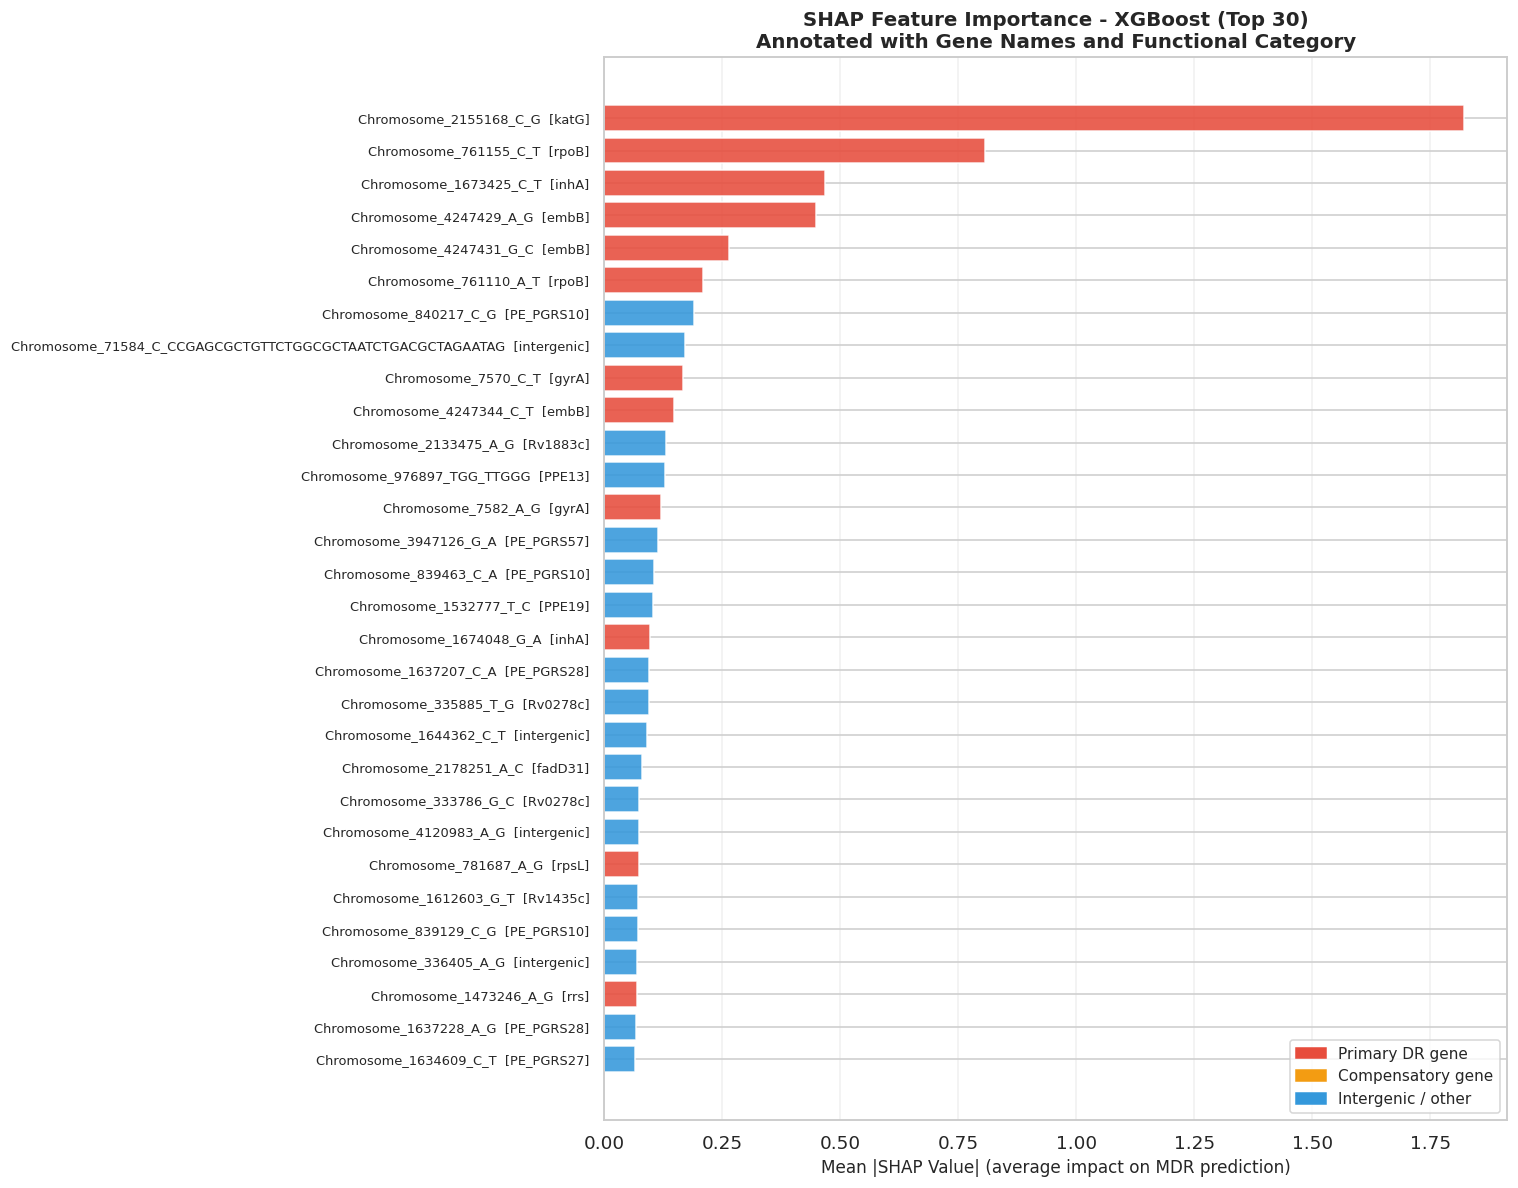

Saved: obj2_shap_top30_annotated.png


In [20]:
top30_ann = top100.head(30).copy()

fig, ax = plt.subplots(figsize=(14, 11))

# Color by gene category
def bar_color(row):
    if row['is_compensatory'] == 1:  return '#f39c12'   # orange — compensatory
    if row['is_primary_DR']   == 1:  return '#e74c3c'   # red    — primary DR
    return '#3498db'                                      # blue   — other/intergenic

colors = [bar_color(row) for _, row in top30_ann[::-1].iterrows()]

# Y-axis labels: variant_id + gene name
labels_y = [
    f"{row['variant_id']}  [{row['gene']}]"
    for _, row in top30_ann[::-1].iterrows()
]

ax.barh(range(30), top30_ann['mean_abs_shap'].values[::-1], color=colors, alpha=0.88, edgecolor='white')
ax.set_yticks(range(30))
ax.set_yticklabels(labels_y, fontsize=8.5)
ax.set_xlabel('Mean |SHAP Value| (average impact on MDR prediction)', fontsize=11)
ax.set_title('SHAP Feature Importance - XGBoost (Top 30)\nAnnotated with Gene Names and Functional Category', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

# Legend
patches = [
    mpatches.Patch(color='#e74c3c', label='Primary DR gene'),
    mpatches.Patch(color='#f39c12', label='Compensatory gene'),
    mpatches.Patch(color='#3498db', label='Intergenic / other'),
]
ax.legend(handles=patches, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_top30_annotated.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: obj2_shap_top30_annotated.png")

### MDR vs non MDR SHAP distributions

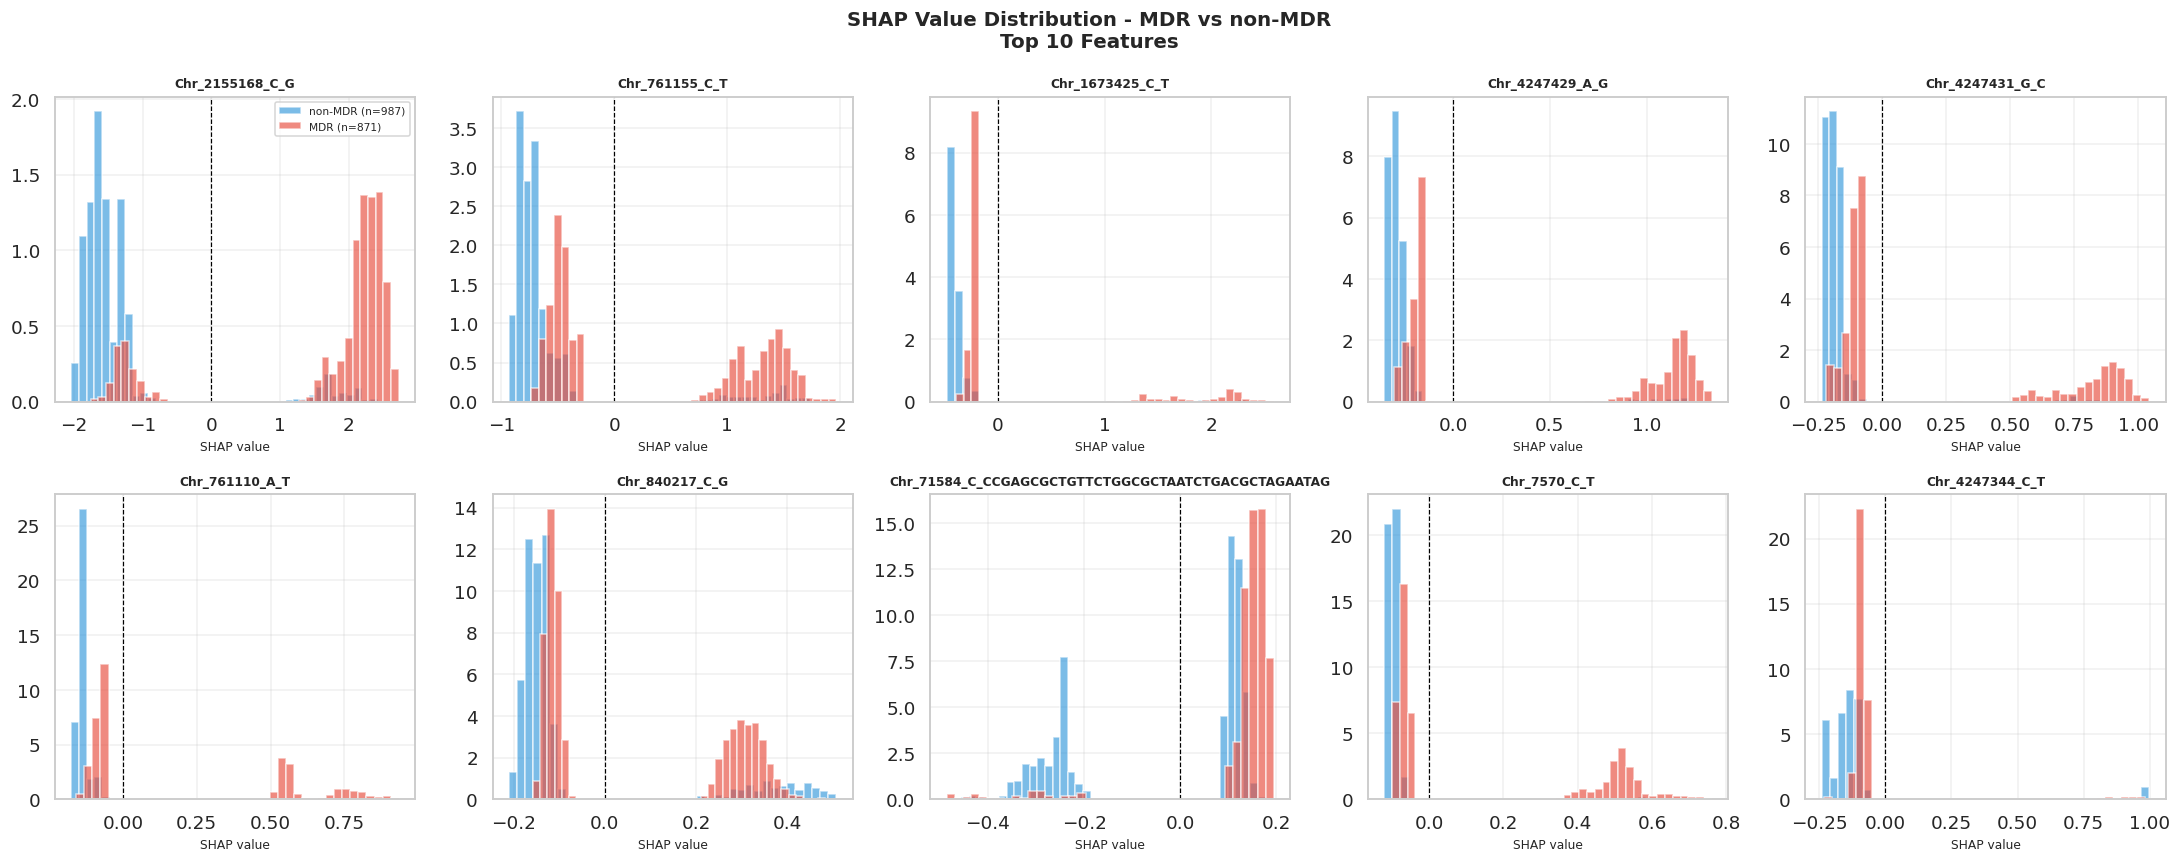

Saved: obj2_shap_mdr_vs_susc_dist.png


In [21]:
# Compare SHAP value distributions between MDR and non-MDR samples
# for the top 10 most important features

top10_idx   = shap_importance.head(10)['feature_idx'].values
top10_names = shap_importance.head(10)['variant_id'].values

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (feat_i, feat_name) in enumerate(zip(top10_idx, top10_names)):
    ax = axes[i]
    shap_mdr  = shap_values[y == 1, feat_i]
    shap_susc = shap_values[y == 0, feat_i]

    ax.hist(shap_susc, bins=40, alpha=0.65, color='#3498db',
            label=f'non-MDR (n={len(shap_susc)})', density=True)
    ax.hist(shap_mdr,  bins=40, alpha=0.65, color='#e74c3c',
            label=f'MDR (n={len(shap_mdr)})',     density=True)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    # Short name for title
    short = feat_name.replace('Chromosome_', 'Chr_')
    ax.set_title(f'{short}', fontsize=8, fontweight='bold')
    ax.set_xlabel('SHAP value', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('SHAP Value Distribution - MDR vs non-MDR\nTop 10 Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_mdr_vs_susc_dist.png'), bbox_inches='tight')
plt.show()
print("Saved: obj2_shap_mdr_vs_susc_dist.png")

### cross model consensus

In [22]:
# Features in top 100 of SHAP AND RF AND EBM = strongest consensus

shap_top100_set = set(shap_importance.head(100)['variant_id'].tolist())

# Load Step 4 importance files
rf_imp  = pd.read_csv(os.path.join(STEP4, 'obj2_rf_top30_features.csv'))
xgb_imp = pd.read_csv(os.path.join(STEP4, 'obj2_xgb_top30_features.csv'))
ebm_imp = pd.read_csv(os.path.join(STEP4, 'obj2_ebm_feature_importance_named.csv'))

rf_top30_set  = set(rf_imp['variant_id'].tolist())
xgb_top30_set = set(xgb_imp['variant_id'].tolist())

# EBM main effects only (no interaction terms)
ebm_main = ebm_imp[~ebm_imp['feature'].str.contains(' & ', na=False)]
ebm_top30_set = set(ebm_main.head(30)['feature'].tolist())

# Consensus groups
in_shap_rf  = shap_top100_set & rf_top30_set
in_shap_ebm = shap_top100_set & ebm_top30_set
in_all3     = shap_top100_set & rf_top30_set & ebm_top30_set

print("=== CROSS-MODEL CONSENSUS ===")
print(f"In SHAP top-100 + RF top-30   : {len(in_shap_rf)}")
print(f"In SHAP top-100 + EBM top-30  : {len(in_shap_ebm)}")
print(f"In SHAP top-100 + RF + EBM    : {len(in_all3)}")

# Build ranked consensus table
shap_ranks = {r['variant_id']: r['rank']
              for _, r in shap_importance.head(100).iterrows()}
rf_ranks   = {r['variant_id']: r['rank']
              for _, r in rf_imp.iterrows()}
ebm_ranks  = {r['feature']: r['rank']
              for _, r in ebm_main.head(100).iterrows()}
xgb_ranks  = {r['variant_id']: r['rank']
              for _, r in xgb_imp.iterrows()}

consensus_rows = []
for feat in in_all3:
    sr = shap_ranks.get(feat, 999)
    rr = rf_ranks.get(feat, 999)
    er = ebm_ranks.get(feat, 999)
    xr = xgb_ranks.get(feat, 999)
    consensus_rows.append({
        'variant_id'    : feat,
        'shap_rank'     : sr,
        'rf_rank'       : rr,
        'ebm_rank'      : er,
        'xgb_rank'      : xr,
        'mean_rank'     : round(np.mean([sr, rr, er]), 1),
    })

consensus_df = pd.DataFrame(consensus_rows).sort_values('mean_rank')
consensus_df.insert(0, 'consensus_rank', range(1, len(consensus_df)+1))

# Annotate with gene names
consensus_df[['gene','is_compensatory','is_primary_DR','gene_source']] = consensus_df.apply(
    lambda r: pd.Series(annotate_pos(r)), axis=1)

print(f"\nFeatures in top of all 3 models:")
print(consensus_df.to_string(index=False))

consensus_df.to_csv(os.path.join(STEP5, 'obj2_shap_consensus_features.csv'), index=False)
print("\nSaved: obj2_shap_consensus_features.csv")

=== CROSS-MODEL CONSENSUS ===
In SHAP top-100 + RF top-30   : 13
In SHAP top-100 + EBM top-30  : 15
In SHAP top-100 + RF + EBM    : 5

Features in top of all 3 models:
 consensus_rank             variant_id  shap_rank  rf_rank  ebm_rank  xgb_rank  mean_rank gene  is_compensatory  is_primary_DR gene_source
              1 Chromosome_2155168_C_G          1        1         1        13        1.0 katG                0              1  tbprofiler
              2  Chromosome_761155_C_T          2        2         2       999        2.0 rpoB                0              1  tbprofiler
              3 Chromosome_4247431_G_C          5        3         7         2        5.0 embB                0              1  tbprofiler
              4 Chromosome_1673425_C_T          3       11         4       999        6.0 inhA                0              1  tbprofiler
              5 Chromosome_4247429_A_G          4       17         5         5        8.7 embB                0              1  tbprofile

### SHAP per lineage analysis

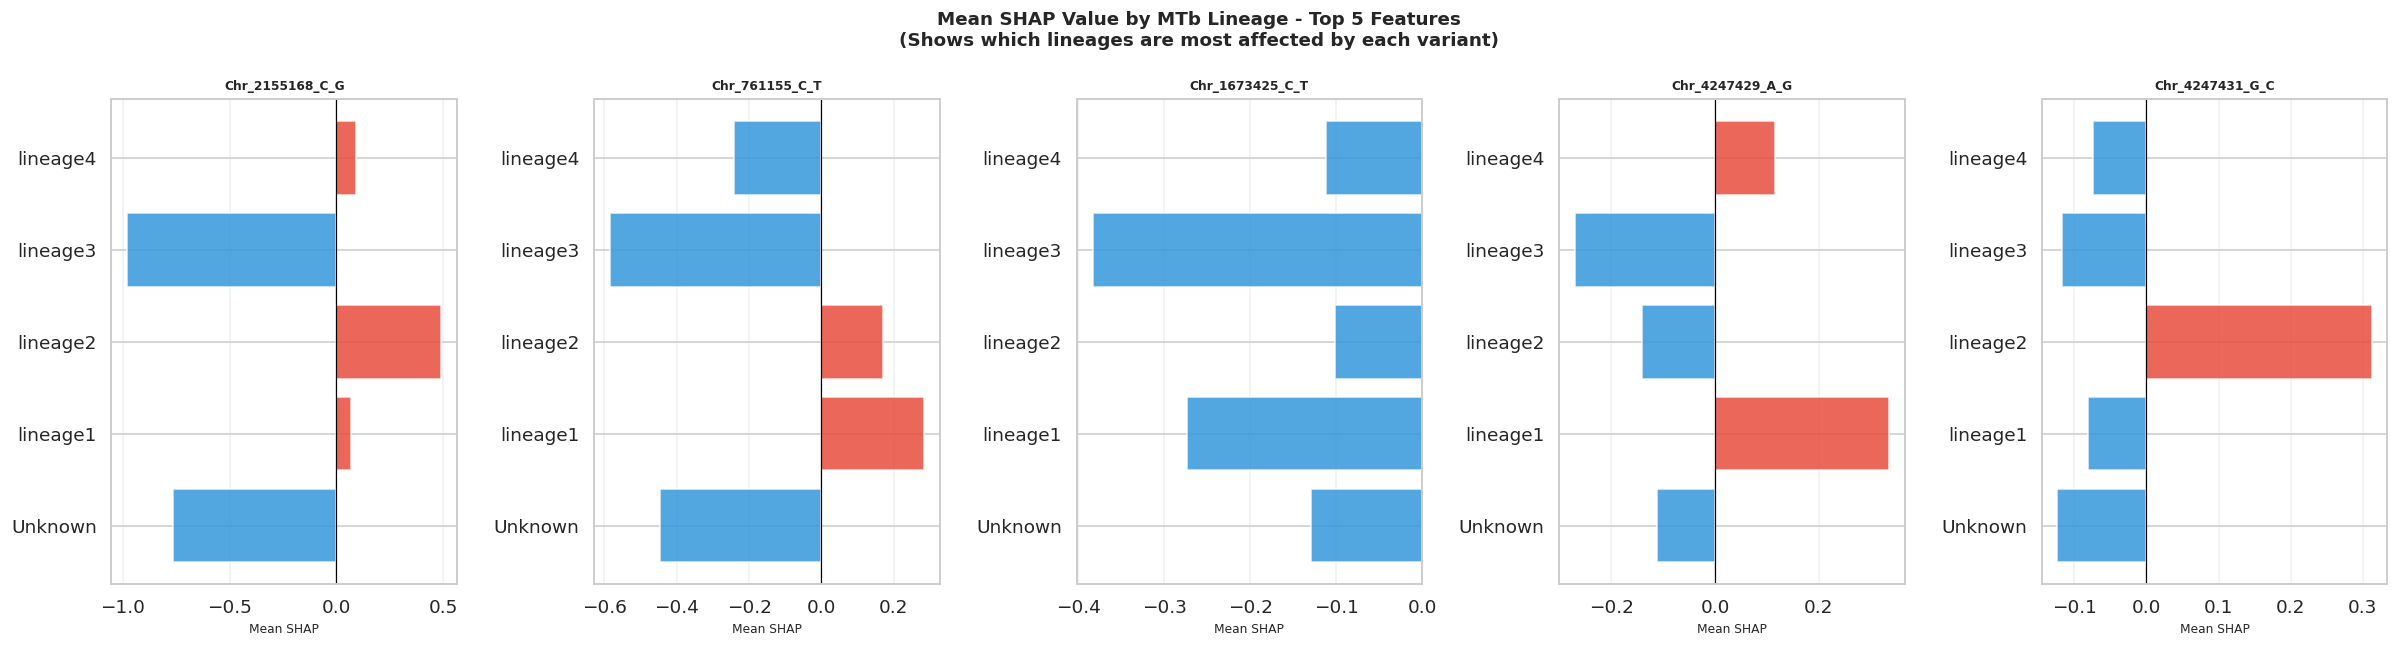

Saved: obj2_shap_by_lineage.png


In [24]:
# Do the top SHAP features affect MDR isolates differently by lineage?
# This bridges Step 5 and Step 7 (lineage analysis for Objective 3)

lineage_col = 'main_lineage'
lineages    = sorted(labels[lineage_col].fillna('Unknown').unique())

top5_idx   = shap_importance.head(5)['feature_idx'].values
top5_names = shap_importance.head(5)['variant_id'].values

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for ax, feat_i, feat_name in zip(axes, top5_idx, top5_names):
    lineage_means = {}
    for lin in lineages:
        lin_mask = (labels[lineage_col].fillna('Unknown') == lin).values
        if lin_mask.sum() >= 10:   # only plot if ≥10 samples
            lineage_means[lin] = shap_values[lin_mask, feat_i].mean()

    if lineage_means:
        lins  = list(lineage_means.keys())
        means = list(lineage_means.values())
        colors_lin = ['#e74c3c' if m > 0 else '#3498db' for m in means]
        ax.barh(lins, means, color=colors_lin, alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(feat_name.replace('Chromosome_','Chr_'),
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Mean SHAP', fontsize=8)
        ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Mean SHAP Value by MTb Lineage - Top 5 Features\n'
             '(Shows which lineages are most affected by each variant)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(STEP5, 'obj2_shap_by_lineage.png'), bbox_inches='tight')
plt.show()
print("Saved: obj2_shap_by_lineage.png")

### Summary 

In [25]:
print("STEP 5 COMPLETE - SHAP ANALYSIS")
print()
print(f"SHAP values computed for {shap_values.shape[0]} samples × "
      f"{shap_values.shape[1]} features")
print(f"Baseline MDR probability    : {explainer.expected_value:.4f}")
print(f"  (prediction when no variant info available)")
print()
print(f"Top 3 SHAP features:")
for _, row in shap_importance.head(3).iterrows():
    print(f"  Rank {row['rank']:>2}: {row['variant_id']:<42} "
          f"mean|SHAP|={row['mean_abs_shap']:.4f}")
print()
print(f"Compensatory gene variants in top 100 SHAP : "
      f"{top100['is_compensatory'].sum()}")
print(f"Primary DR gene variants in top 100 SHAP  : "
      f"{top100['is_primary_DR'].sum()}")
print(f"Cross-model consensus features (all 3)     : "
      f"{len(consensus_df)}")
print()
print("Output files:")
for fname in sorted(os.listdir(STEP5)):
    fpath = os.path.join(STEP5, fname)
    size  = os.path.getsize(fpath)
    print(f"  {fname:<48} {size/1024:>8.1f} KB")
print()
print("Next: step6_ebm_analysis.ipynb - EBM shape functions deep dive")

STEP 5 COMPLETE - SHAP ANALYSIS

SHAP values computed for 1858 samples × 94583 features
Baseline MDR probability    : 0.0366
  (prediction when no variant info available)

Top 3 SHAP features:
  Rank  1: Chromosome_2155168_C_G                     mean|SHAP|=1.8224
  Rank  2: Chromosome_761155_C_T                      mean|SHAP|=0.8060
  Rank  3: Chromosome_1673425_C_T                     mean|SHAP|=0.4678

Compensatory gene variants in top 100 SHAP : 1
Primary DR gene variants in top 100 SHAP  : 15
Cross-model consensus features (all 3)     : 5

Output files:
  gene_annotation_conflicts.csv                        12.9 KB
  obj2_shap_all_features.csv                         5069.7 KB
  obj2_shap_beeswarm.png                              411.0 KB
  obj2_shap_by_lineage.png                             51.0 KB
  obj2_shap_compensatory_features.csv                   0.2 KB
  obj2_shap_consensus_features.csv                      0.4 KB
  obj2_shap_mdr_vs_susc_dist.png                      10